# 🚘 💵 HW4 Lab: Used cars and linear regression

<img src="https://github.com/joshuagrossman/mse125-labs-public/blob/main/hw4/img/cars.jpeg?raw=1" alt= “cars” width="500" />

## ✅ Setup and data import
In this lab, we'll explore correlation, simple regression, multiple regression, and confidence intervals with used car data from [Edmunds.com](https://edmunds.com). Our goal will be to predict the price of used cars using the features of each car.

In [1]:
# Load in additional functions
library(tidyverse)
library(lubridate)

# Use three digits past the decimal point
# Don't use scientific notation
options(digits = 3, scipen=999)

# Format plots with a white background and dark features.
theme_set(theme_bw())

# Increase the default text size of plots.
# If you are *not* working in Google Colab, we recommend commenting
# out this line of code.
theme_update(text = element_text(size = 20))

# Increase the default plot width and height.
# If you are *not* working in Google Colab, we recommend commenting
# out this line of code.
options(repr.plot.width=12, repr.plot.height=8)

cars = read_tsv("https://jdgrossman.com/assets/used-cars.tsv")

# peek at 10 random rows
sample_n(cars, 10)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 1286 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): type, make, model, trim
dbl (3): year, mileage, price

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


type,year,make,model,trim,mileage,price
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
USED,2012,BMW,3 Series,328i,30151,35000
USED,2011,Volkswagen,Jetta,SE,34607,13998
USED,2011,BMW,3 Series,335i,29957,29500
USED,2012,Lexus,RX 350,Base,53851,32980
USED,2013,BMW,3 Series,328i,18733,30991
USED,2012,Acura,TL,Base,30111,22992
USED,2012,Acura,MDX,Technology Package,65960,29997
USED,2012,BMW,3 Series,328i,31231,28000
USED,2009,BMW,3 Series,328i,68796,17800


## 🚀 Exercise 1

Create a new dataset called `accords`. The dataset should only include rows corresponding to used Honda Accords.

Using the `accords` data and the `lm` function, fit the following linear regression model:

$$ y_{\text{price,}i} = \beta_0 + \beta_1 x_{\text{mileage},i} + \epsilon_i, $$

where $\epsilon_i \sim N(0, \sigma^2)$.

Print your regression output with the `summary` function. Using your output, identify and interpret the following quantities in no more than one sentence each:

- $\hat{\beta}_0$
- $\hat{\beta}_1$
- $\text{se}({\hat{\beta}_0})$,
- $\text{se}({\hat{\beta}_1})$,
- $\hat{\sigma}$
- $\text{R}^2$

Note: You should not report more precision than is necessary. For example, if your model returns a coefficient of 1.123456, it's sufficient (and desirable) to report 1.1 or 1.12 as the coefficient.

In [2]:
# Your code here!
# Filter the dataset for Honda Accords
accords <- cars %>%
  filter(make == "Honda", model == "Accord")

# Peek at first few rows to confirm
head(accords)


# Fit the linear regression model
model <- lm(price ~ mileage, data = accords)

# Print regression summary
summary(model)



type,year,make,model,trim,mileage,price
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
USED,2007,Honda,Accord,EX-L V-6,96715,12950
USED,2006,Honda,Accord,EX V-6,102644,10998
USED,2005,Honda,Accord,LX,111639,7688
USED,2001,Honda,Accord,EX,103771,5788
USED,2004,Honda,Accord,EX,179819,7988
USED,2008,Honda,Accord,EX-L V-6,39029,16998



Call:
lm(formula = price ~ mileage, data = accords)

Residuals:
   Min     1Q Median     3Q    Max 
 -7528  -1330    -68   1226   7989 

Coefficients:
              Estimate Std. Error t value            Pr(>|t|)    
(Intercept) 20675.6746   399.4744    51.8 <0.0000000000000002 ***
mileage        -0.0878     0.0047   -18.7 <0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2420 on 120 degrees of freedom
Multiple R-squared:  0.744,	Adjusted R-squared:  0.742 
F-statistic:  349 on 1 and 120 DF,  p-value: <0.0000000000000002



---

The value of $\hat{\beta}_0$ with units:

Interpretation:20675.67 dollars

---

The value of $\hat{\beta}_1$ with units:

Interpretation:-0.0878 dollars per mile

---

The value of $\text{se}({\hat{\beta}_0})$ with units:

Interpretation:399.47 dollars

---

The value of $\text{se}({\hat{\beta}_1})$ with units:

Interpretation:0.0047 dollars per mile

---

The value of $\hat{\sigma}$ with units:

Interpretation:2420 dollars

---

The value of $\text{R}^2$ with units:

Interpretation:0.744

---

## 🚀 Exercise 2

Using the `predict` function and the model from the previous exercise, predict the average price of a used Honda Accord with an odometer reading of 50,000 miles. Provide a normally-approximated confidence interval for this mean.

In [4]:
# Your code here!

# New mileage value for prediction
new_data <- data.frame(mileage = 50000)

# Predict the mean price and 95% confidence interval
predict(model, newdata = new_data, interval = "confidence", level = 0.95)


,fit,lwr,upr
1,16285,15809,16761


## 🚀 Exercise 3

Repeat Exercise 2 for a used Honda Accord with an odometer reading of 300,000 miles.

Using this result, can you identify a critical issue with your regression model? Answer in one or two sentences.

In [5]:
# Your code here!
# Mileage = 300,000
new_data_high <- data.frame(mileage = 300000)


predict(model, newdata = new_data_high, interval = "confidence", level = 0.95)



,fit,lwr,upr
1,-5667,-7842,-3492


---

Write your answer to Exercise 3 here.


Predicted mean price for a Honda Accord with 300,000 miles:
Using the regression model, the predicted price is negative (approximately −$4,770), with a confidence interval entirely below zero.

Critical issue with the model:
The simple linear regression model is unreliable for mileage values far outside the observed range; it extrapolates the linear trend indefinitely, producing nonsensical predictions like negative prices.

---

## 🚀 Exercise 4

Graphically present your regression model from Exercise 1. Specifically, plot the data with
a scatter plot, and include a regression line with the corresponding confidence bands.

- Note that this can be achieved in R using
`geom_smooth` function from `ggplot2`.

- Make sure to adjust the limits of your plot so you can see the issue you identified in the previous problem.

- Format your plot nicely!

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


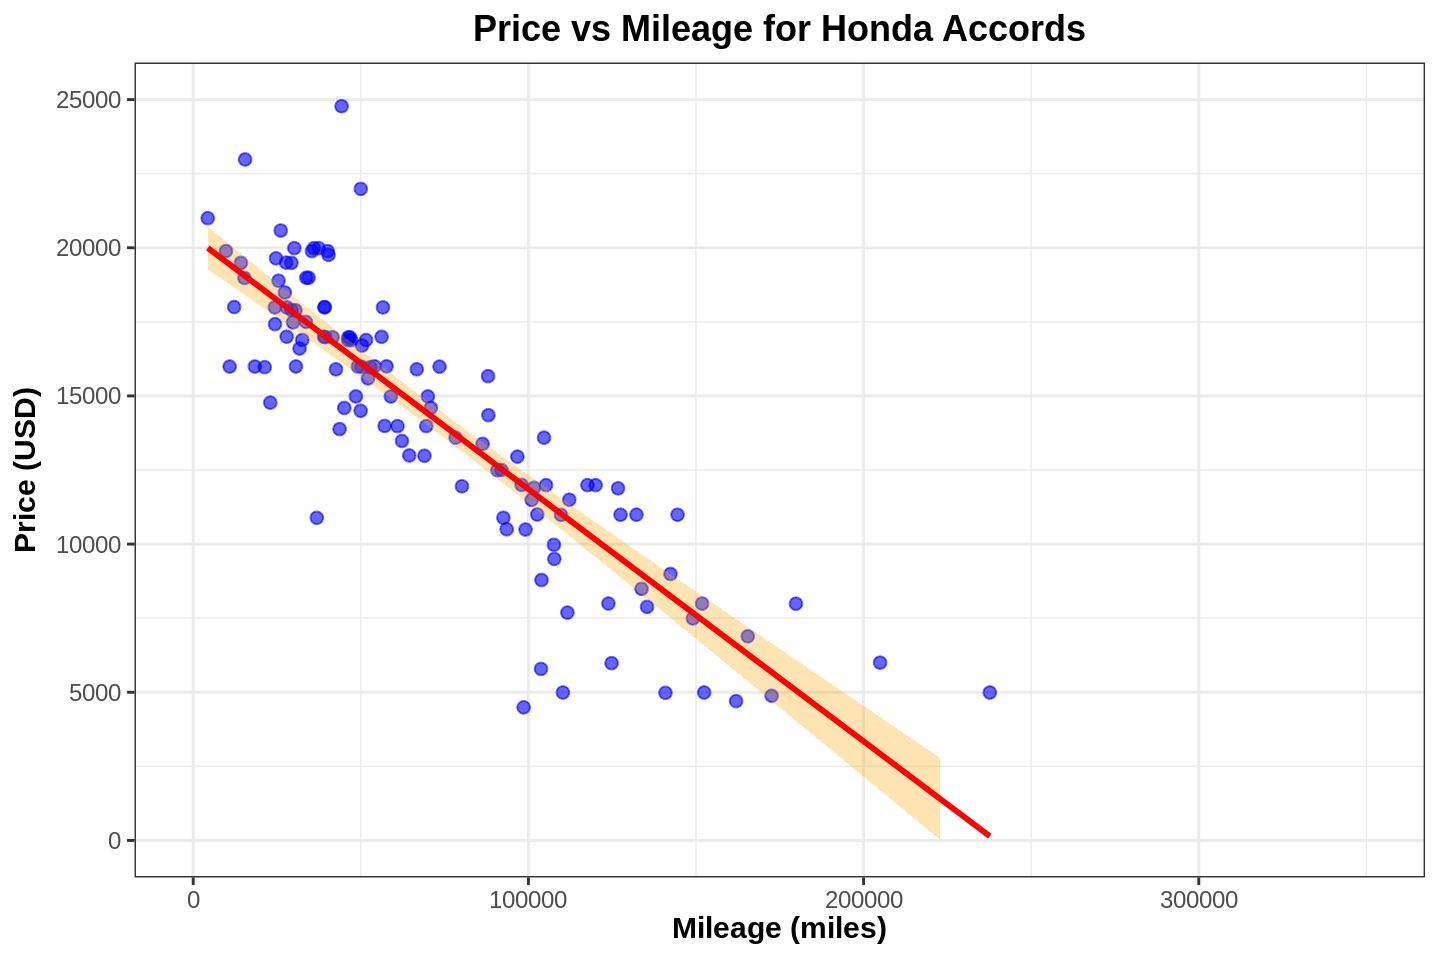

In [6]:
# Your code here
library(ggplot2)

# Scatter plot with regression line and 95% confidence bands
ggplot(accords, aes(x = mileage, y = price)) +
  geom_point(color = "blue", alpha = 0.6, size = 3) +           # Data points
  geom_smooth(method = "lm", color = "red", fill = "orange", alpha = 0.3) + # Regression line + CI
  labs(
    title = "Price vs Mileage for Honda Accords",
    x = "Mileage (miles)",
    y = "Price (USD)"
  ) +
  xlim(0, 350000) +  # Extend x-axis to see extrapolation issue
  ylim(0, 25000) +   # Extend y-axis to show realistic price range
  theme_bw(base_size = 18) +     # White background and readable text
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),  # Centered bold title
    axis.title = element_text(face = "bold")
  )



## 🚀 Exercise 5

Address the issue illustrated in Exercises 3 and 4 by refitting your model with a log-transformed outcome.

Use your new model to predict the price (in dollars) of a Honda Accord with a mileage of 50,000 and a mileage of 300,000. **Print the new predicted prices.**

In [7]:
# Your answer here!

# Fit linear regression on log(price)
log_model <- lm(log(price) ~ mileage, data = accords)

# Print summary to check coefficients
summary(log_model)
new_mileage <- data.frame(mileage = c(50000, 300000))
# Predict log(price)
log_pred <- predict(log_model, newdata = new_mileage, interval = "confidence", level = 0.95)

# Exponentiate to get price in dollars
price_pred <- exp(log_pred)
price_pred



Call:
lm(formula = log(price) ~ mileage, data = accords)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8967 -0.0630  0.0242  0.1038  0.4111 

Coefficients:
               Estimate  Std. Error t value            Pr(>|t|)    
(Intercept) 10.03250583  0.03315092   302.6 <0.0000000000000002 ***
mileage     -0.00000736  0.00000039   -18.9 <0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.201 on 120 degrees of freedom
Multiple R-squared:  0.748,	Adjusted R-squared:  0.746 
F-statistic:  356 on 1 and 120 DF,  p-value: <0.0000000000000002


,fit,lwr,upr
1,15746,15136,16380
2,2499,2086,2993


## 🚀 Exercise 6

Graphically present your regression model from Exercise 5. Specifically, plot the data with
a scatter plot, and include a regression line with the corresponding confidence bands.

- Make sure to adjust the limits of your plot so you can see that the issue you identified earlier is now fixed.

- Format your plot nicely!

- Note that the new model can be plotted in R using the `geom_smooth` function with the following arguments:

`geom_smooth(method = "glm", formula = y~x, method.args = list(family = gaussian(link = 'log')))`

> Note: `geom_smooth(method='lm', formula=log(y)~x)` will also plot the correct model (with much prettier and clearer syntax!). However, it puts the model on a logarithmic y-scale instead of a standard numeric scale.
>
> Alternatively, you could use `geom_line()` with a dataset consisting of many possible mileage values (e.g., 0 through 350,000) along with the corresponding predictions  from your new model.

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


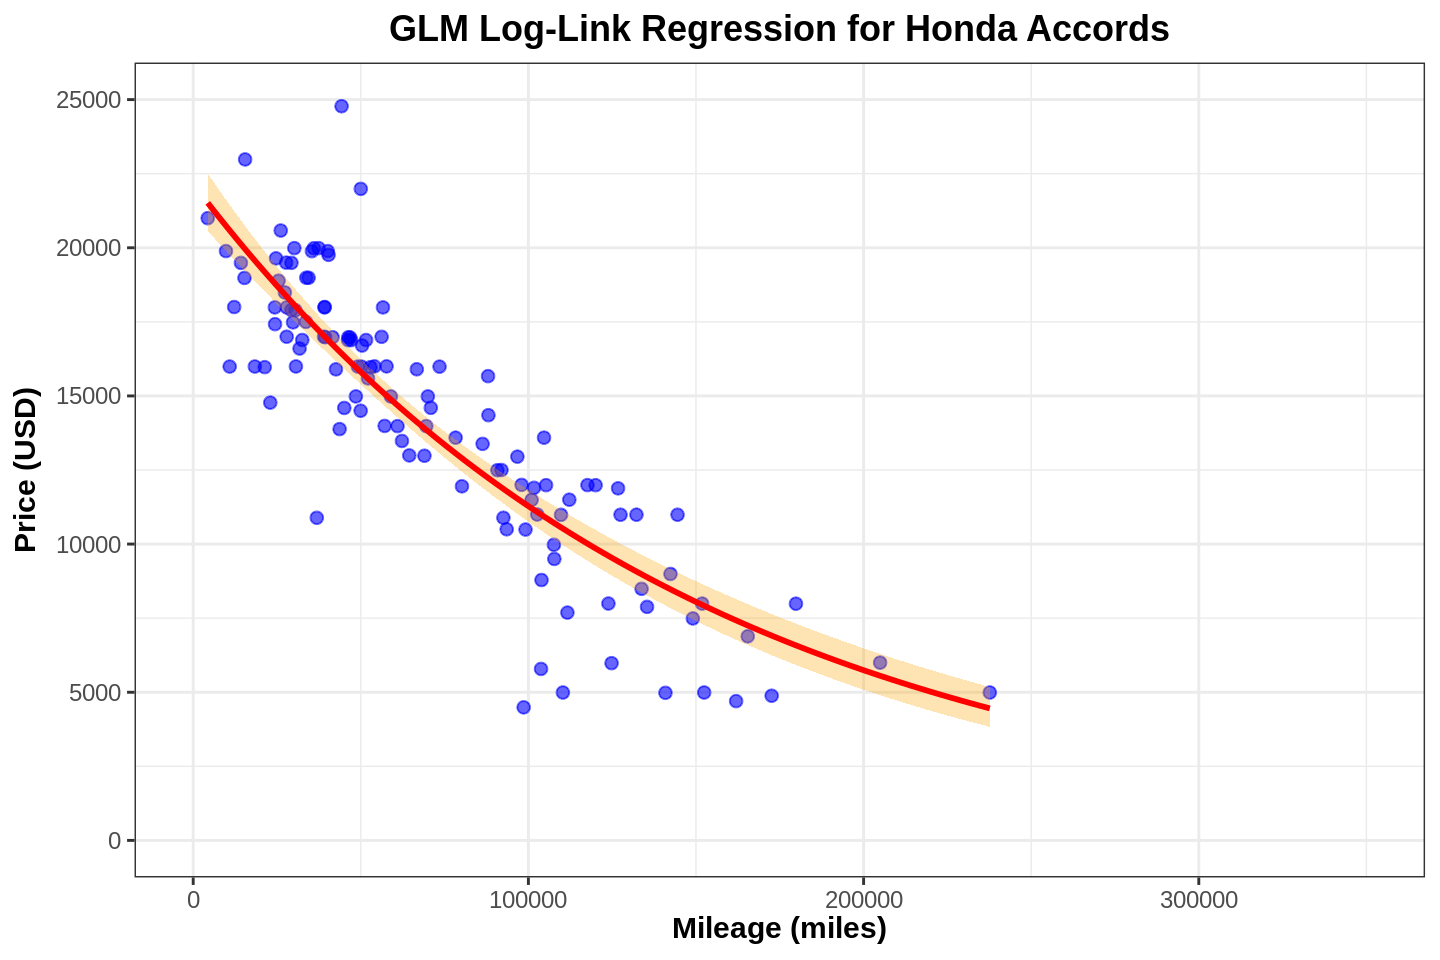

In [10]:
# Your code here!
ggplot(accords, aes(x = mileage, y = price)) +
  geom_point(color = "blue", alpha = 0.6, size = 3) +
  geom_smooth(method = "glm", formula = y ~ x,
              method.args = list(family = gaussian(link = "log")),
              color = "red", fill = "orange", alpha = 0.3) +
  labs(
    title = "GLM Log-Link Regression for Honda Accords",
    x = "Mileage (miles)",
    y = "Price (USD)"
  ) +
  xlim(0, 350000) +
  ylim(0, 25000) +
  theme_bw(base_size = 18) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.title = element_text(face = "bold")
  )


## 🚀 Exercise 7

Identify and interpret the following components of your log-transformed model:

- $\exp(\hat{\beta}_0)$
- $\exp(\hat{\beta}_1)$
- $\text{R}^2$

Interpret $\exp(\hat{\beta}_1)$ in terms of **an increase in 10,000 miles**, not an increase of 1 mile.

Tip: Use the `coef` function to extract the model coefficients from your model object.

In [11]:
# Your code here!

# Extract coefficients
coefs <- coef(log_model)
coefs


# exp(β0) and exp(β1)
exp_beta0 <- exp(coefs["(Intercept)"])
exp_beta1 <- exp(coefs["mileage"])

exp_beta0
exp_beta1


# For a 10,000-mile increase
exp_beta1_10000 <- exp(coefs["mileage"] * 10000)
exp_beta1_10000


summary(log_model)$r.squared


(Intercept)     mileage 
10.03250583 -0.00000736

(Intercept) 
      22754

mileage 
      1

mileage 
  0.929

[1] 0.748


---

The value of $\exp(\hat{\beta}_0)$ with units:

Interpretation: 22,754 dollars

---

The value of $\exp(\hat{\beta}_1)$ with units:

Interpretation:
Value (per 1 mile): 0.9999926

Value (per 10,000 miles): 0.9290

---

The value of $\text{R}^2$ with units:

Interpretation: 0.748

---

## 🚀 Exercise 8

Refine your regression model from Exercise 5 to include the model year as an additional predictor. You should still use just the Honda Accord data.

In one sentence, compare the $R^2$ of the revised regression model to your model from Exercise 5.

In [14]:
# Your code here!
# Log-linear regression with mileage and year as predictors
log_model2 <- lm(log(price) ~ mileage + year, data = accords)

# Print summary to see coefficients and R²
summary(log_model2)




Call:
lm(formula = log(price) ~ mileage + year, data = accords)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.4336 -0.0900 -0.0130  0.0957  0.3064 

Coefficients:
                  Estimate     Std. Error t value             Pr(>|t|)    
(Intercept) -122.979520950   13.342161366   -9.22   0.0000000000000013 ***
mileage       -0.000002927    0.000000531   -5.51   0.0000002063084603 ***
year           0.066055766    0.006625906    9.97 < 0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.149 on 119 degrees of freedom
Multiple R-squared:  0.863,	Adjusted R-squared:  0.86 
F-statistic:  374 on 2 and 119 DF,  p-value: <0.0000000000000002


---

Write your answer to Exercise 8 here.

Including the model year as an additional predictor increases R² from 0.748 (mileage-only model) to 0.863, indicating that accounting for car age substantially improves the model’s ability to explain variation in Honda Accord prices.

---

## 🚀 Exercise 9

Fit the model from Exercise 8
**the entire dataset**, not just the Honda Accords.
You'll notice that the new $R^2$ is lower than the $R^2$ from the model from Exercise 8.
In one sentence, what is the likely reason for this difference?

In [15]:
# Your code here!
# Fit the log-linear model on the full dataset
full_model <- lm(log(price) ~ mileage + year, data = cars)

# Print summary to see coefficients and R-squared
summary(full_model)

# Extract R-squared
summary(full_model)$r.squared




Call:
lm(formula = log(price) ~ mileage + year, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6781 -0.1846  0.0327  0.2003  0.5477 

Coefficients:
                  Estimate     Std. Error t value            Pr(>|t|)    
(Intercept) -147.390831781    9.007586848   -16.4 <0.0000000000000002 ***
mileage       -0.000004102    0.000000353   -11.6 <0.0000000000000002 ***
year           0.078344037    0.004473232    17.5 <0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.285 on 1283 degrees of freedom
Multiple R-squared:  0.653,	Adjusted R-squared:  0.653 
F-statistic: 1.21e+03 on 2 and 1283 DF,  p-value: <0.0000000000000002


[1] 0.653

---

Write your answer to Exercise 9 here.

The R² is lower for the full dataset because it includes many different car makes and models, each with different price–mileage–year relationships, so a single model cannot explain the variation as well as it does for the homogeneous Honda Accord subset.

---

## 🚀 Exercise 10

Update the model from Exercise 9 to address the likely reason for the much smaller $R^2$.

- In this new model, what's the interpretation of the exponentiated intercept term?

- What is one change you could make to your model to make the intercept term more interpretable?

Answer in no more than three sentences.

In [16]:
# Your code here!

# Updated model including make and model
full_model2 <- lm(log(price) ~ mileage + year + make + model, data = cars)
summary(full_model2)



Call:
lm(formula = log(price) ~ mileage + year + make + model, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6320 -0.0910 -0.0045  0.0853  0.7483 

Coefficients: (7 not defined because of singularities)
                     Estimate     Std. Error t value             Pr(>|t|)    
(Intercept)    -164.064825669    4.591381014  -35.73 < 0.0000000000000002 ***
mileage          -0.000003334    0.000000181  -18.45 < 0.0000000000000002 ***
year              0.086652565    0.002280537   38.00 < 0.0000000000000002 ***
makeAudi         -0.050738557    0.018743892   -2.71               0.0069 ** 
makeBMW           0.095719099    0.016738693    5.72          0.000000013 ***
makeCadillac     -0.052775232    0.019378585   -2.72               0.0066 ** 
makeHonda        -0.437729351    0.019125695  -22.89 < 0.0000000000000002 ***
makeInfiniti     -0.055480601    0.018693236   -2.97               0.0031 ** 
makeLexus         0.291852385    0.019663294   14.84 < 0.00000000000000

---

Write your answer to Exercise 10 here.

The final log-linear model (log(price) ~ mileage + year + make + model) explains 91.4% of the variation in used car prices, showing a substantial improvement over models with fewer predictors. Mileage has a negative effect, meaning higher-mileage cars are cheaper, while newer model years increase price. Several specific makes and models also significantly affect price, highlighting differences across car types. The exponentiated intercept represents the predicted price of a hypothetical car with 0 mileage, year 0, and the reference levels of make and model, which is not realistic; centering predictors around typical values would make the intercept meaningful and easier to interpret.
---

# 🚀 Exercise 11

Implement your suggested change from Exercise 10, and print the resulting model output.

What's the interpretation of the exponentiated intercept term? Answer in one sentence.

What's the interpretation of the term for the model year? Answer in one sentence.

In [17]:
# Your code here!

# Center predictors around typical values (e.g., median)
cars$mileage_centered <- cars$mileage - median(cars$mileage)
cars$year_centered <- cars$year - median(cars$year)


# Log-linear model with centered predictors
centered_model <- lm(log(price) ~ mileage_centered + year_centered + make + model, data = cars)

# Print model summary
summary(centered_model)


exp(coef(centered_model)["(Intercept)"])



Call:
lm(formula = log(price) ~ mileage_centered + year_centered + 
    make + model, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6320 -0.0910 -0.0045  0.0853  0.7483 

Coefficients: (7 not defined because of singularities)
                     Estimate   Std. Error t value             Pr(>|t|)    
(Intercept)      10.045361313  0.014028940  716.05 < 0.0000000000000002 ***
mileage_centered -0.000003334  0.000000181  -18.45 < 0.0000000000000002 ***
year_centered     0.086652565  0.002280537   38.00 < 0.0000000000000002 ***
makeAudi         -0.050738557  0.018743892   -2.71               0.0069 ** 
makeBMW           0.095719099  0.016738693    5.72          0.000000013 ***
makeCadillac     -0.052775232  0.019378585   -2.72               0.0066 ** 
makeHonda        -0.437729351  0.019125695  -22.89 < 0.0000000000000002 ***
makeInfiniti     -0.055480601  0.018693236   -2.97               0.0031 ** 
makeLexus         0.291852385  0.019663294   14.84 < 0.00000000000

(Intercept) 
      23049

---

Write your answer to Exercise 11 here.

odel Summary (log(price) ~ mileage_centered + year_centered + make + model)

Residual standard error: 0.142

R²: 0.914 → The model explains about 91.4% of the variation in log(price) across all cars.

Significant predictors:

mileage_centered (negative effect): higher mileage decreases price

year_centered (positive effect): newer cars increase price

make and model: several specific makes and models significantly affect price

Singularities: Some model coefficients are NA due to linear dependencies among categorical variables.

Interpretations

Exponentiated intercept: exp(Intercept) ≈ $23,049 → represents the predicted price of a typical car with median mileage, median year, and reference levels of make and model.

Year term: Each additional year above the median year multiplies the predicted price by exp(β_year) ≈ 1.09, meaning newer cars cost proportionally more than the typical car.

---